In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
df=pd.read_csv("C:\\Users\\verseelia\\Desktop\\clus\\single_genre_artists.csv")

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors

In [23]:
df.shape

(95837, 23)

In [24]:
df.head()

,id_songs,name_song,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists
0,0IA0Hju8CAgYfV1hwhidBH,La Java,0,161427,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.563,0.184,4,...,0.993,0.000016,0.325,0.654,133.088,3,5078.0,['vintage chanson'],Mistinguett,22
1,1b8HZQCqcqwbzlA1jRTp6E,En Douce,0,223440,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.427,0.180,10,...,0.989,0.000000,0.128,0.431,78.459,3,5078.0,['vintage chanson'],Mistinguett,22
2,5d5gQxHwYovxR5pqETOIAa,J'en Ai Marre,0,208267,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.511,0.206,0,...,0.995,0.000000,0.418,0.481,70.443,4,5078.0,['vintage chanson'],Mistinguett,22
3,1EO65UEEPfy7CR0NK2sDxy,Ils n'ont pas ca,0,161933,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.676,0.467,9,...,0.991,0.000000,0.219,0.726,129.775,4,5078.0,['vintage chanson'],Mistinguett,22
4,6a58gXSgqbIsXUhVZ6ZJqe,La belote,0,167973,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.650,0.298,9,...,0.991,0.000000,0.373,0.844,75.950,4,5078.0,['vintage chanson'],Mistinguett,22


In [25]:
df.info()
print()
print("Missing values:")
print(df.isna().sum())


<class 'pandas.DataFrame'>
RangeIndex: 95837 entries, 0 to 95836
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_songs            95837 non-null  str    
 1   name_song           95837 non-null  str    
 2   popularity_songs    95837 non-null  int64  
 3   duration_ms         95837 non-null  int64  
 4   explicit            95837 non-null  int64  
 5   id_artists          95837 non-null  str    
 6   release_date        95837 non-null  str    
 7   danceability        95837 non-null  float64
 8   energy              95837 non-null  float64
 9   key                 95837 non-null  int64  
 10  loudness            95837 non-null  float64
 11  mode                95837 non-null  int64  
 12  speechiness         95837 non-null  float64
 13  acousticness        95837 non-null  float64
 14  instrumentalness    95837 non-null  float64
 15  liveness            95837 non-null  float64
 16  valence        

In [26]:
feature_cols = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo',
    'duration_ms',
    
]

In [27]:
df[feature_cols].describe()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,9.583700e+04
mean,0.586853,0.541083,-10.157862,0.168832,0.458989,0.082145,0.224916,0.574281,117.539870,2.087320e+05
std,0.155422,0.236304,4.748798,0.275417,0.330416,0.232440,0.185829,0.248126,30.190399,1.177526e+05
min,0.000000,0.000020,-50.174000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.373000e+03
25%,0.488000,0.365000,-12.723000,0.034100,0.133000,0.000000,0.100000,0.378000,94.829000,1.573330e+05
50%,0.605000,0.542000,-9.397000,0.046200,0.453000,0.000004,0.149000,0.589000,116.595000,2.040000e+05
75%,0.700000,0.727000,-6.692000,0.103000,0.759000,0.001300,0.302000,0.780000,135.975000,2.502670e+05
max,0.991000,1.000000,5.376000,0.968000,0.996000,1.000000,0.997000,1.000000,239.906000,4.800118e+06


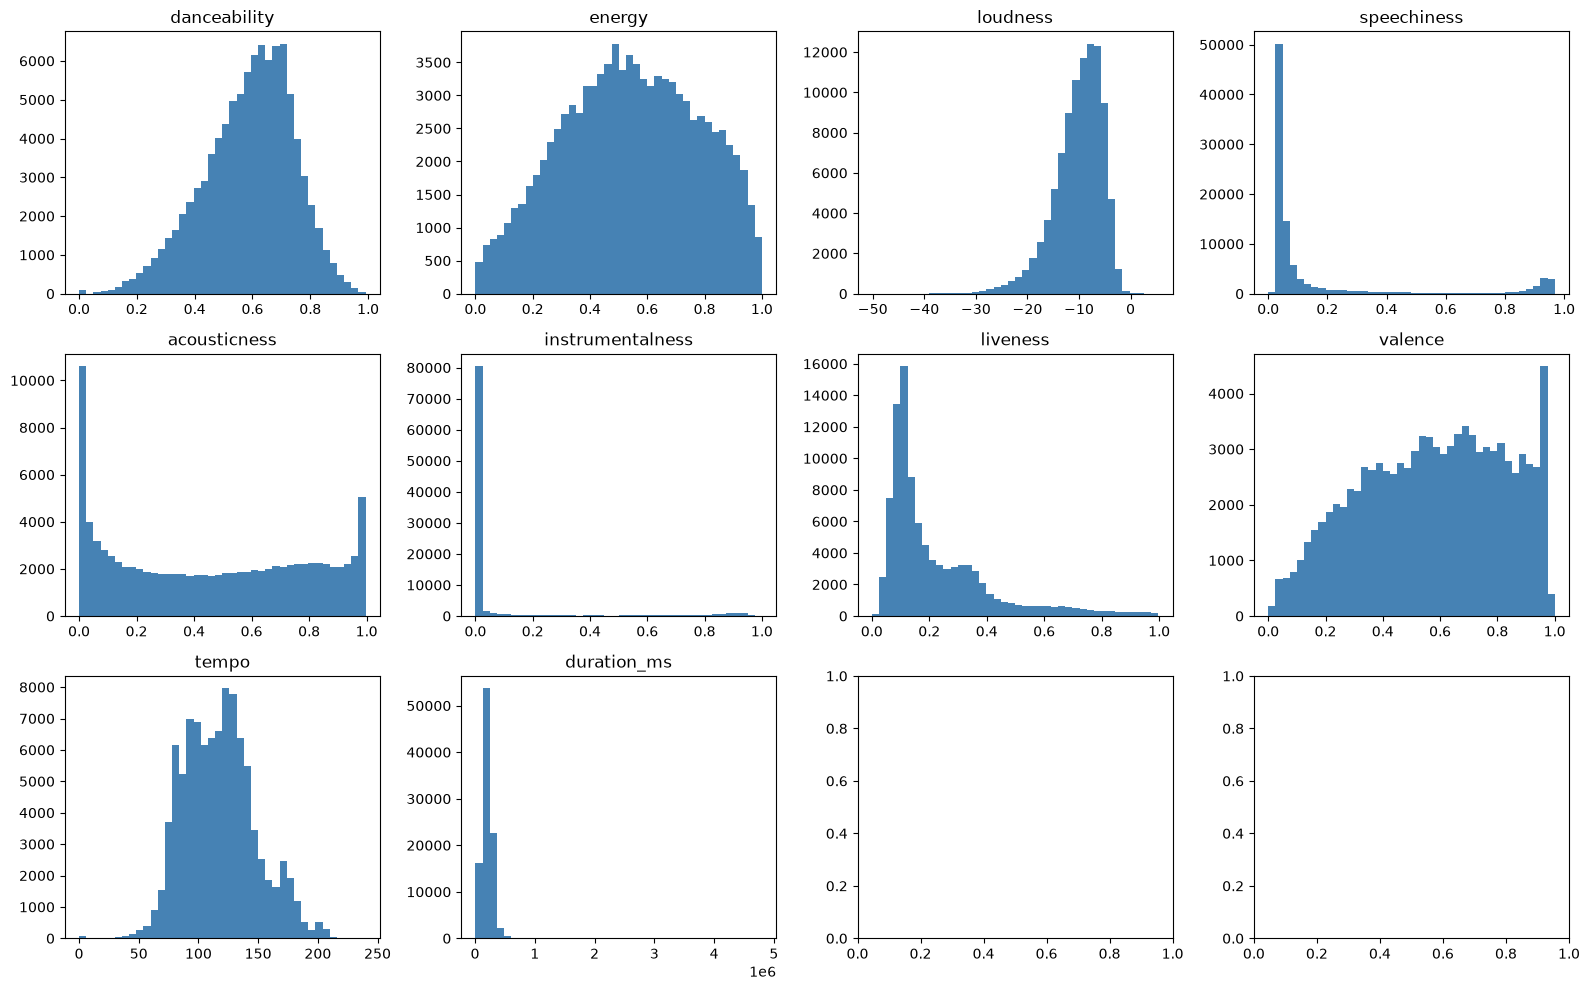

In [28]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, col in zip(axes.flatten(), feature_cols):
    ax.hist(df[col], bins=40, color="steelblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()


In [29]:
print("Unique genres:", df["genres"].nunique())
df["genres"].value_counts().head(10)


Unique genres: 3153


genres
['hoerspiel']              8027
['kleine hoerspiel']       2081
[]                         1876
['classic israeli pop']    1180
['vintage taiwan pop']     1097
['classic thai pop']        939
['j-pop']                   911
['turkish pop']             846
['indonesian pop']          813
['chanson']                 769
Name: count, dtype: int64

In [30]:
X_raw = df[feature_cols].copy()

# log1p transform for skewed features
X_raw["instrumentalness"] = np.log1p(X_raw["instrumentalness"])
X_raw["speechiness"] = np.log1p(X_raw["speechiness"])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print("Scaled feature matrix shape:", X_scaled.shape)


Scaled feature matrix shape: (95837, 10)


In [31]:
# Clustering will use this directly — no PCA reduction applied to it
X_cluster = X_scaled
print("Feature matrix used for CLUSTERING (no PCA):", X_cluster.shape)


Feature matrix used for CLUSTERING (no PCA): (95837, 10)


2D PCA (visualization only) explains 45.91% of variance


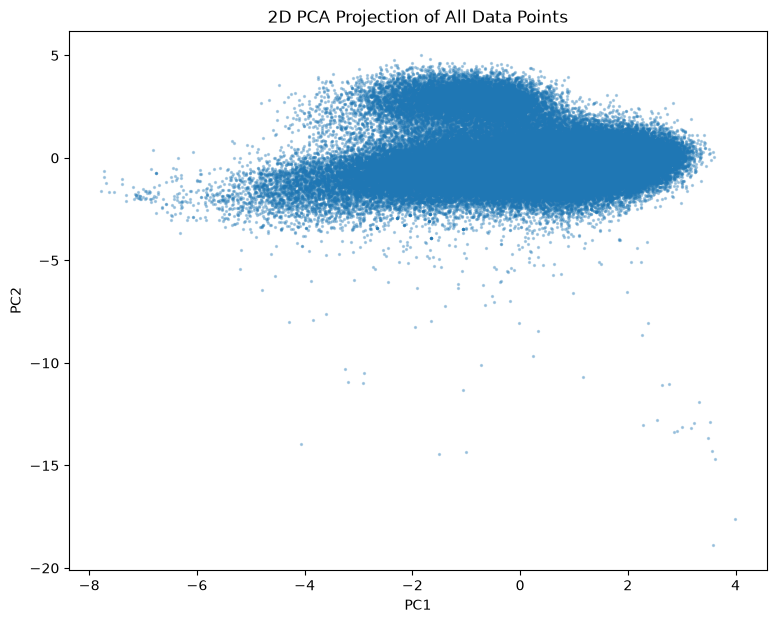

In [32]:
# 2D PCA projection — VISUALIZATION ONLY

RANDOM_STATE = 42

pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)

X_pca_2d = pca_2d.fit_transform(X_scaled)

print(
    f"2D PCA (visualization only) explains "
    f"{pca_2d.explained_variance_ratio_.sum():.2%} of variance"
)

# Plot ALL data points
plt.figure(figsize=(9, 7))

plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    s=2,
    alpha=0.3
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D PCA Projection of All Data Points")
plt.show()

In [33]:
k_range = range(2, 13)
inertias, sil_scores, db_scores, ch_scores = [], [], [], []

sil_sample_idx = rng.choice(len(X_cluster), size=8000, replace=False)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_cluster)

    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster[sil_sample_idx], labels[sil_sample_idx]))
    db_scores.append(davies_bouldin_score(X_cluster, labels))
    ch_scores.append(calinski_harabasz_score(X_cluster, labels))

    print(f"k={k:2d} | inertia={km.inertia_:>10.1f} | silhouette={sil_scores[-1]:.3f} "
          f"| davies_bouldin={db_scores[-1]:.3f} | calinski_harabasz={ch_scores[-1]:.1f}")

k= 2 | inertia=  779469.2 | silhouette=0.202 | davies_bouldin=1.942 | calinski_harabasz=21995.7
k= 3 | inertia=  659198.9 | silhouette=0.242 | davies_bouldin=1.575 | calinski_harabasz=21746.7
k= 4 | inertia=  595045.3 | silhouette=0.233 | davies_bouldin=1.542 | calinski_harabasz=19504.7
k= 5 | inertia=  551021.4 | silhouette=0.191 | davies_bouldin=1.699 | calinski_harabasz=17711.2
k= 6 | inertia=  523572.5 | silhouette=0.160 | davies_bouldin=1.710 | calinski_harabasz=15916.5
k= 7 | inertia=  492757.2 | silhouette=0.167 | davies_bouldin=1.562 | calinski_harabasz=15091.9
k= 8 | inertia=  463496.2 | silhouette=0.168 | davies_bouldin=1.495 | calinski_harabasz=14616.6
k= 9 | inertia=  438697.0 | silhouette=0.176 | davies_bouldin=1.472 | calinski_harabasz=14189.5
k=10 | inertia=  417917.6 | silhouette=0.175 | davies_bouldin=1.427 | calinski_harabasz=13769.3
k=11 | inertia=  404599.5 | silhouette=0.165 | davies_bouldin=1.463 | calinski_harabasz=13115.6
k=12 | inertia=  392107.9 | silhouette=0

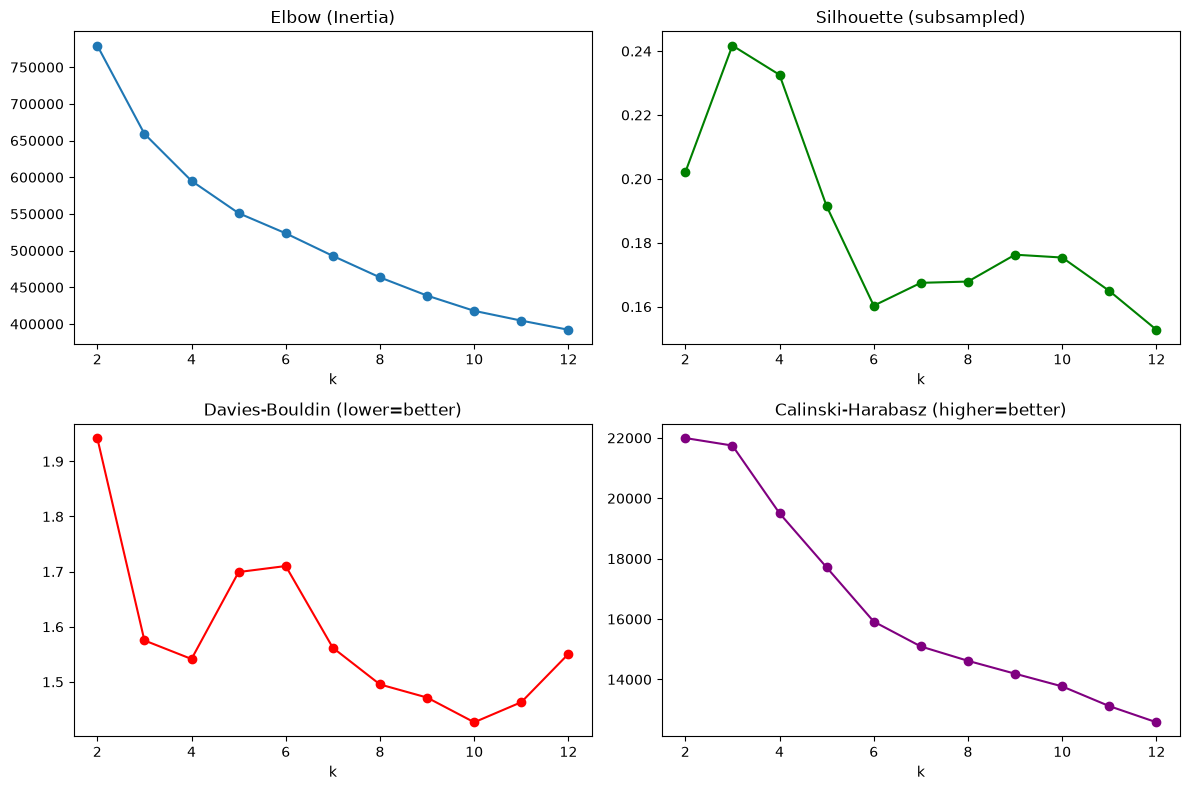

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0,0].plot(list(k_range), inertias, marker="o"); axes[0,0].set_title("Elbow (Inertia)")
axes[0,1].plot(list(k_range), sil_scores, marker="o", color="green"); axes[0,1].set_title("Silhouette (subsampled)")
axes[1,0].plot(list(k_range), db_scores, marker="o", color="red"); axes[1,0].set_title("Davies-Bouldin (lower=better)")
axes[1,1].plot(list(k_range), ch_scores, marker="o", color="purple"); axes[1,1].set_title("Calinski-Harabasz (higher=better)")
for ax in axes.flatten():
    ax.set_xlabel("k")
plt.tight_layout()
plt.show()


In [35]:
K_MEANS_BEST_K = 3  # <-- update after reviewing the plots

kmeans_final = KMeans(n_clusters=K_MEANS_BEST_K, random_state=RANDOM_STATE, n_init=10)
df["cluster_kmeans"] = kmeans_final.fit_predict(X_cluster)

kmeans_sil = silhouette_score(X_cluster[sil_sample_idx], df["cluster_kmeans"].values[sil_sample_idx])
kmeans_db = davies_bouldin_score(X_cluster, df["cluster_kmeans"])
kmeans_ch = calinski_harabasz_score(X_cluster, df["cluster_kmeans"])

print(f"K-Means (k={K_MEANS_BEST_K}) -> silhouette={kmeans_sil:.3f}, "
      f"davies_bouldin={kmeans_db:.3f}, calinski_harabasz={kmeans_ch:.1f}")
df["cluster_kmeans"].value_counts().sort_index()

K-Means (k=3) -> silhouette=0.242, davies_bouldin=1.575, calinski_harabasz=21746.7


cluster_kmeans
0    52277
1    30664
2    12896
Name: count, dtype: int64

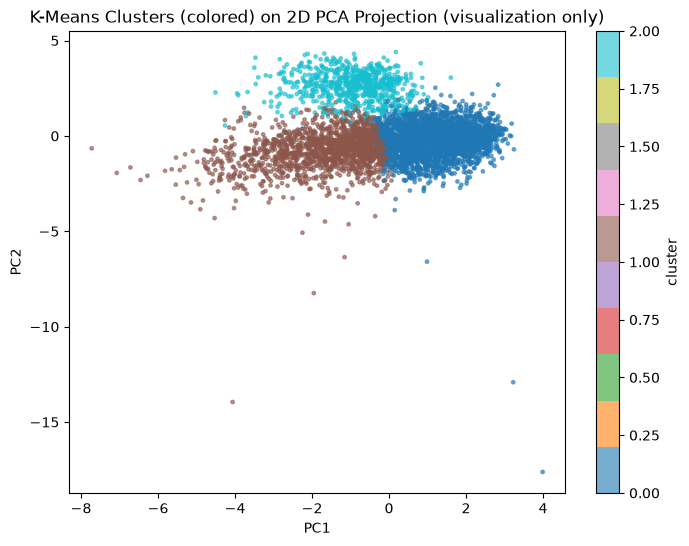

In [36]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca_2d[plot_idx, 0], X_pca_2d[plot_idx, 1],
                       c=df["cluster_kmeans"].values[plot_idx], cmap="tab10", s=6, alpha=0.6)
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("K-Means Clusters (colored) on 2D PCA Projection (visualization only)")
plt.colorbar(scatter, label="cluster")
plt.show()

In [37]:
n_components_range = range(2, 13)
bic_scores, gmm_sil_scores = [], []

for n in n_components_range:
    gmm = GaussianMixture(n_components=n, random_state=RANDOM_STATE, covariance_type="full")
    gmm.fit(X_cluster)
    labels = gmm.predict(X_cluster)

    bic_scores.append(gmm.bic(X_cluster))
    gmm_sil_scores.append(silhouette_score(X_cluster[sil_sample_idx], labels[sil_sample_idx]))

    print(f"n_components={n:2d} | BIC={bic_scores[-1]:>12.1f} | silhouette={gmm_sil_scores[-1]:.3f}")

n_components= 2 | BIC=   1639547.3 | silhouette=0.103
n_components= 3 | BIC=   1304861.7 | silhouette=0.077
n_components= 4 | BIC=   1221228.0 | silhouette=0.021
n_components= 5 | BIC=   1190013.1 | silhouette=0.012
n_components= 6 | BIC=   1169695.2 | silhouette=-0.019
n_components= 7 | BIC=   1122388.4 | silhouette=-0.016
n_components= 8 | BIC=   1103885.5 | silhouette=-0.041
n_components= 9 | BIC=   1075569.7 | silhouette=-0.004
n_components=10 | BIC=   1035024.1 | silhouette=-0.013
n_components=11 | BIC=   1019770.7 | silhouette=-0.016
n_components=12 | BIC=   1020046.9 | silhouette=-0.041


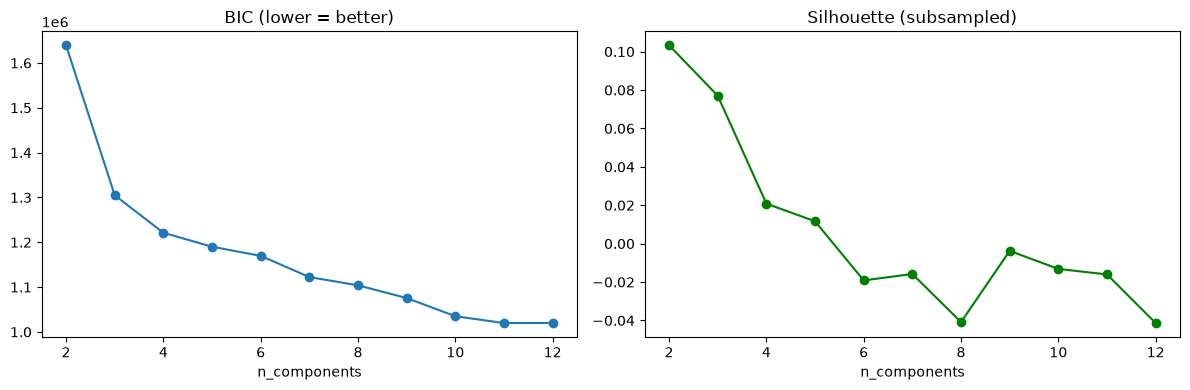

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(n_components_range), bic_scores, marker="o")
axes[0].set_title("BIC (lower = better)"); axes[0].set_xlabel("n_components")
axes[1].plot(list(n_components_range), gmm_sil_scores, marker="o", color="green")
axes[1].set_title("Silhouette (subsampled)"); axes[1].set_xlabel("n_components")
plt.tight_layout()
plt.show()

In [39]:
GMM_BEST_N = 2 # <-- update after reviewing the plots

gmm_final = GaussianMixture(n_components=GMM_BEST_N, random_state=RANDOM_STATE, covariance_type="full")
df["cluster_gmm"] = gmm_final.fit_predict(X_cluster)

gmm_sil = silhouette_score(X_cluster[sil_sample_idx], df["cluster_gmm"].values[sil_sample_idx])
gmm_db = davies_bouldin_score(X_cluster, df["cluster_gmm"])
gmm_ch = calinski_harabasz_score(X_cluster, df["cluster_gmm"])

print(f"GMM (n={GMM_BEST_N}) -> silhouette={gmm_sil:.3f}, davies_bouldin={gmm_db:.3f}, calinski_harabasz={gmm_ch:.1f}")
df["cluster_gmm"].value_counts().sort_index()

GMM (n=2) -> silhouette=0.103, davies_bouldin=3.648, calinski_harabasz=6474.2


cluster_gmm
0    40176
1    55661
Name: count, dtype: int64

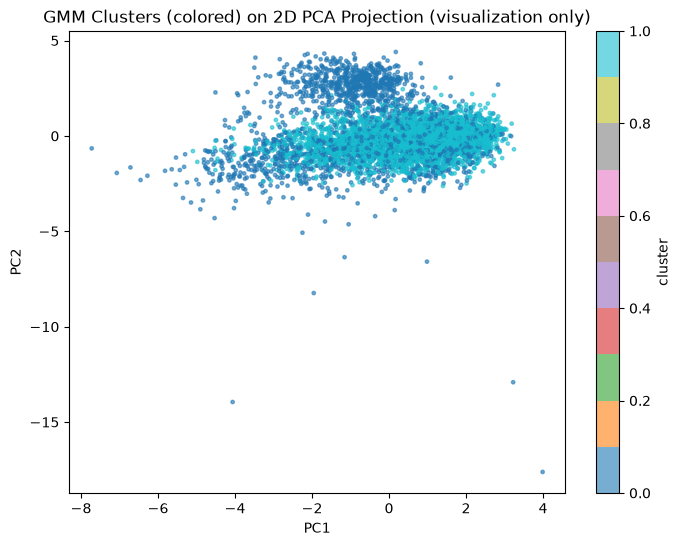

In [40]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca_2d[plot_idx, 0], X_pca_2d[plot_idx, 1],
                       c=df["cluster_gmm"].values[plot_idx], cmap="tab10", s=6, alpha=0.6)
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("GMM Clusters (colored) on 2D PCA Projection (visualization only)")
plt.colorbar(scatter, label="cluster")
plt.show()


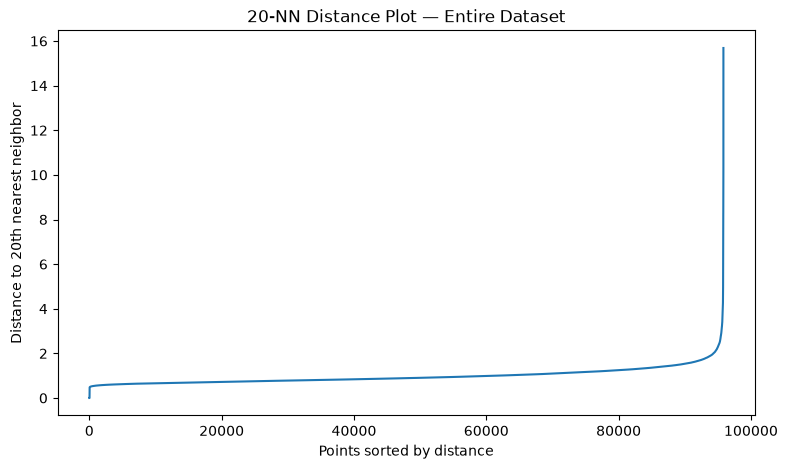

In [42]:
nn = NearestNeighbors(n_neighbors=20)
nn.fit(X_cluster)

distances, _ = nn.kneighbors(X_cluster)

k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(9, 5))
plt.plot(k_distances)

plt.xlabel("Points sorted by distance")
plt.ylabel("Distance to 20th nearest neighbor")
plt.title("20-NN Distance Plot — Entire Dataset")

plt.show()

In [44]:
DBSCAN_EPS = 2.0       # <-- update based on the elbow in the plot above
DBSCAN_MIN_SAMPLES = 20  # <-- rule of thumb: >= 2 * n_features

dbscan = DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_SAMPLES)
df["cluster_dbscan"] = dbscan.fit_predict(X_cluster)

n_clusters_dbscan = len(set(df["cluster_dbscan"])) - (1 if -1 in df["cluster_dbscan"].values else 0)
n_noise = (df["cluster_dbscan"] == -1).sum()
print(f"DBSCAN found {n_clusters_dbscan} clusters, {n_noise} noise points ({n_noise/len(df):.1%})")

# Silhouette only makes sense excluding noise, and only if >= 2 clusters remain
mask = df["cluster_dbscan"].values[sil_sample_idx] != -1
if df["cluster_dbscan"].nunique() > 1 and mask.sum() > 0:
    dbscan_sil = silhouette_score(X_cluster[sil_sample_idx][mask], df["cluster_dbscan"].values[sil_sample_idx][mask])
    print(f"Silhouette (excluding noise) = {dbscan_sil:.3f}")
else:
    print("Not enough clusters to compute silhouette — try adjusting eps/min_samples.")

df["cluster_dbscan"].value_counts().sort_index()

MemoryError: 